# Cobertura de cotizaciones PAPER — diagnóstico reproducible

## tl;dr

La simulación original mide 60 s con 1 grupo de entrada, 240 s con 2 entradas y 2 runners, 360 s con 3 entradas y 1 runner, 300 s con 5 entradas, 360 s con 6 entradas y 7.680 s con 64 entradas y 64 runners. La alternancia puede superar el límite financiero de 300 s incluso con cuatro grupos. Son escenarios sintéticos de carga continua, no rentabilidad ni cobertura observada del mercado.

## Context & Methods

Pregunta: ¿una cotización adicional por minuto puede mantener cada grupo de valoración dentro de los 300 segundos exigidos por la aceptación financiera?

### Key Assumptions

- Escenarios sintéticos: todos los grupos están abiertos y requieren una valoración continua.
- Un grupo representa un token y una cantidad raw exacta; brazos con la misma cantidad pueden compartir una respuesta, nunca su base financiera.
- Cada tick dura 60 segundos. Se usa `forward_budget.claim` original, con orden runner → entrada y alternancia cuando ambos bancos tienen demanda.
- Se selecciona el grupo menos recientemente valorado dentro de cada banco.
- Sin fallos de proveedor, ventas pendientes, entradas nuevas ni reutilización de cotizaciones primarias. Es una prueba favorable de capacidad secundaria, no una estimación del mercado.
- Las escrituras de reserva se aíslan en `TemporaryDirectory`. No se inicia el bot ni se consultan proveedores.

In [1]:
import datetime as dt
import inspect
import json
import sys
from pathlib import Path
from tempfile import TemporaryDirectory

candidate = Path.cwd().resolve()
project = next(p for p in [candidate, *candidate.parents] if (p / 'research_loop/forward_budget.py').is_file())
sys.path.insert(0, str(project))
from research_loop import forward_budget

cadence_s = 60
cash_gap_limit_s = 300
claim_source = inspect.getsource(forward_budget.claim)
assert '(stamp - previous).total_seconds() < 60' in claim_source
cash_source = (project / 'research_loop/runner_forward.py').read_text(encoding='utf-8')
assert '(stamp - previous_at).total_seconds() > 300' in cash_source
print({'secondary_quote_cadence_s': cadence_s, 'cash_gap_limit_s': cash_gap_limit_s})

{'secondary_quote_cadence_s': 60, 'cash_gap_limit_s': 300}


## Data

Fuentes: `research_loop/forward_budget.py`, `research_loop/paired_forward.py`, `research_loop/runner_forward.py`, `research_loop/entry_gate_forward.py`, y los escenarios definidos abajo. Los datos calculados tienen una fila por escenario de carga, no por trade.

La existencia de `data/research` se comprueba solo en modo lectura. Una carpeta ausente no equivale a cero oportunidades ni permite calcular una cobertura histórica.

In [2]:
research_path_exists = (project / 'data/research').is_dir()
print({'research_path_exists_at_execution': research_path_exists, 'observed_market_coverage': None})

{'research_path_exists_at_execution': False, 'observed_market_coverage': None}


### Simular reservas originales

Se registran intervalos entre reservas sucesivas de cada grupo, después de su primera reserva. Todos los grupos deben recibir al menos dos reservas para poder medirlos. Las reservas cuentan incluso ante un fallo, igual que el contrato original; aquí se asume éxito para aislar la capacidad.

In [3]:
def simulate_capacity(entry_groups, runner_groups, ticks=384):
    owners = {'runner_exit': runner_groups, 'entry_gate': entry_groups}
    histories = {(owner, group): [] for owner, count in owners.items() for group in range(count)}
    epoch = dt.datetime(2026, 10, 8, tzinfo=dt.timezone.utc)
    with TemporaryDirectory(prefix='memebot-capacity-') as sandbox:
        for tick in range(ticks):
            stamp = epoch + dt.timedelta(seconds=tick * cadence_s)
            accepted_this_tick = 0
            for owner, count in owners.items():
                if not count:
                    continue
                other = 'entry_gate' if owner == 'runner_exit' else 'runner_exit'
                group = min(range(count), key=lambda item: (histories[(owner, item)][-1] if histories[(owner, item)] else -1, item))
                if forward_budget.claim(sandbox, owner, other_pending=owners[other] > 0,
                                        now=stamp, request_id=f'{owner}-{group}'):
                    histories[(owner, group)].append(tick * cadence_s)
                    accepted_this_tick += 1
            assert accepted_this_tick <= 1
    intervals = {key: [b - a for a, b in zip(times, times[1:])] for key, times in histories.items()}
    assert all(values for values in intervals.values())
    maxima = {key: max(values) for key, values in intervals.items()}
    return {'entry_groups': entry_groups, 'runner_groups': runner_groups,
            'groups': entry_groups + runner_groups, 'max_interval_s': max(maxima.values()),
            'groups_over_gap_limit': sum(value > cash_gap_limit_s for value in maxima.values()),
            'observed_reservations': sum(len(times) for times in histories.values())}

scenarios = [(1, 0), (2, 2), (3, 1), (5, 0), (6, 0), (64, 64)]
results = [simulate_capacity(*scenario) for scenario in scenarios]
assert [row['max_interval_s'] for row in results] == [60, 240, 360, 300, 360, 7680]
assert [row['groups_over_gap_limit'] for row in results] == [0, 0, 3, 0, 6, 128]
print(json.dumps(results, indent=2))

[
  {
    "entry_groups": 1,
    "runner_groups": 0,
    "groups": 1,
    "max_interval_s": 60,
    "groups_over_gap_limit": 0,
    "observed_reservations": 384
  },
  {
    "entry_groups": 2,
    "runner_groups": 2,
    "groups": 4,
    "max_interval_s": 240,
    "groups_over_gap_limit": 0,
    "observed_reservations": 384
  },
  {
    "entry_groups": 3,
    "runner_groups": 1,
    "groups": 4,
    "max_interval_s": 360,
    "groups_over_gap_limit": 3,
    "observed_reservations": 384
  },
  {
    "entry_groups": 5,
    "runner_groups": 0,
    "groups": 5,
    "max_interval_s": 300,
    "groups_over_gap_limit": 0,
    "observed_reservations": 384
  },
  {
    "entry_groups": 6,
    "runner_groups": 0,
    "groups": 6,
    "max_interval_s": 360,
    "groups_over_gap_limit": 6,
    "observed_reservations": 384
  },
  {
    "entry_groups": 64,
    "runner_groups": 64,
    "groups": 128,
    "max_interval_s": 7680,
    "groups_over_gap_limit": 128,
    "observed_reservations": 384
  }
]


## Results

La figura compara los cinco escenarios pequeños. El escenario de 128 grupos se conserva en la tabla anterior: su escala es demasiado distinta para una comparación legible en el mismo gráfico.

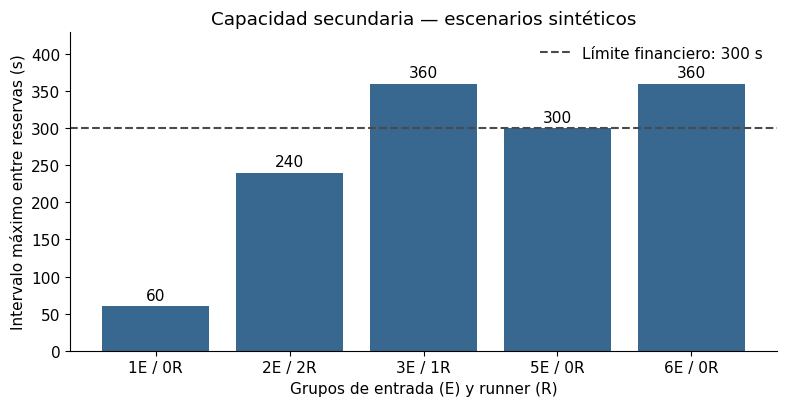

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 11, 'figure.figsize': (8, 4.2), 'axes.spines.top': False, 'axes.spines.right': False})
small = results[:5]
labels = [f"{row['entry_groups']}E / {row['runner_groups']}R" for row in small]
values = [row['max_interval_s'] for row in small]
fig, ax = plt.subplots()
ax.bar(labels, values, color='#38688f')
ax.axhline(cash_gap_limit_s, color='#4a4a4a', linestyle='--', label='Límite financiero: 300 s')
for index, value in enumerate(values):
    ax.text(index, value + 9, str(value), ha='center')
ax.set_ylim(0, max(values) + 70)
ax.set_title('Capacidad secundaria — escenarios sintéticos')
ax.set_xlabel('Grupos de entrada (E) y runner (R)')
ax.set_ylabel('Intervalo máximo entre reservas (s)')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Takeaways

Con 3 entradas y 1 runner, los tres grupos de entrada exceden 300 s pese a que la carga total es solo de cuatro grupos. Con 6 entradas, los seis grupos exceden ese límite; con 128 grupos continuos lo exceden todos. La aceptación financiera debe seguir rechazando esa cobertura incompleta. Las cotizaciones primarias reutilizables pueden mejorar la capacidad sin aumentar peticiones, solo cuando token y cantidad raw exacta coinciden. No transfieren beneficios, propietarios, picos ni ejecuciones entre posiciones. La carpeta de investigación estaba ausente al ejecutar este notebook, por lo que no se mide cobertura real ni rentabilidad. Sigue siendo necesaria aceptación prospectiva de la estrategia y sus costes.